In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from twopoint import twopoint
import plot
from numpy.lib import recfunctions as rfn
import os


In [2]:
weaklens_dir = Path.cwd().parent.parent
run_dir = weaklens_dir / "clean_sims" / "LSSTY5" / "fiducial2pt" / "A"


In [3]:
# Load in the data

import pickle

npairs_dict = {}

for i in range(0, 5):
    for j in range(0, i + 1):
        pickle_file = run_dir / "results/gg_r{0}{1}.pickle".format(j, i)
        print(pickle_file)
        with open(pickle_file, 'rb') as f:
            gg_data = pickle.load(f)
            npairs_dict[(j + 1, i + 1)] = gg_data.npairs

cross_xip = {}
cross_xim = {}
theta_corr = {}

# Load the xip and jackknife uncertainty in xip from treecorr for each binning
for i in range(0, 5):
    for j in range(0, i + 1):
        cross_xip[(j + 1, i + 1)] = np.load(run_dir / "results/xip_corr_r{0}{1}.npy".format(j, i))
        cross_xim[(j + 1, i + 1)] = np.load(run_dir / "results/xim_corr_r{0}{1}.npy".format(j, i))
        theta_corr[(j + 1, i + 1)] = np.load(run_dir / "results/theta_corr_r{0}{1}.npy".format(j, i))

/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r00.pickle


/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r01.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r11.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r02.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r12.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r22.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r03.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r13.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r23.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r33.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r04.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r14.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r24.pickle
/home/shrihan/weaklens/clean_sims/LSSTY5/fiducial2pt/A/results/gg_r34.pickle

In [4]:
fpath = Path("old_runs/giulia_2pt/giulia_2pt_example.fits")
ffile = fits.open(fpath)
del ffile[4:6] # remove gamma_t and wtheta
del ffile[-1] # remove nz_lens

In [5]:
ffile.info()

Filename: old_runs/giulia_2pt/giulia_2pt_example.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (1000, 1000)   float64   
  2  xip           1 BinTableHDU     39   200R x 8C   [K, K, K, D, D, D, D, D]   
  3  xim           1 BinTableHDU     39   200R x 8C   [K, K, K, D, D, D, D, D]   
  4  nz_source     1 BinTableHDU     32   300R x 7C   [D, D, D, D, D, D, D]   


In [6]:
xip_data = ffile[2].data
xim_data = ffile[3].data

# Build extended arrays with 300 rows
n_old = len(xip_data)       # 200
n_new = 15 * 20             # 300

def extend_data(old_data, n_new):
    new_data = np.recarray(n_new, dtype=old_data.dtype)
    # Copy old rows
    for name in old_data.dtype.names:
        new_data[name][:len(old_data)] = old_data[name]
    return new_data

xip_data_new = extend_data(xip_data, n_new)
xim_data_new = extend_data(xim_data, n_new)

# Fill in BIN1, BIN2, ANGBIN, ANGLEMIN, ANGLEMAX, ANG for the new 100 rows
for j in range(5 * 20):
    i = n_old + j 
    bin_num = j // 20 + 1
    ang_bin = xip_data['ANGBIN'][j]
    angle_min = xip_data['ANGLEMIN'][j]
    angle_max = xip_data['ANGLEMAX'][j]
    ang = xip_data['ANG'][j]
    xip_data_new['BIN1'][i] = bin_num
    xip_data_new['BIN2'][i] = 5
    xip_data_new['ANGBIN'][i] = ang_bin
    xip_data_new['ANGLEMIN'][i] = angle_min
    xip_data_new['ANGLEMAX'][i] = angle_max
    xip_data_new['ANG'][i] = ang
    xim_data_new['BIN1'][i] = bin_num
    xim_data_new['BIN2'][i] = 5
    xim_data_new['ANGBIN'][i] = ang_bin
    xim_data_new['ANGLEMIN'][i] = angle_min
    xim_data_new['ANGLEMAX'][i] = angle_max
    xim_data_new['ANG'][i] = ang

val_xip = np.zeros(15 * 20)
val_xim = np.zeros(15 * 20)
npairs = np.zeros(15 * 20)

for i in range(len(val_xip)):
    val_xip[i] = cross_xip[(xip_data_new['BIN1'][i], xip_data_new['BIN2'][i])][xip_data_new['ANGBIN'][i]]
    val_xim[i] = cross_xim[(xim_data_new['BIN1'][i], xim_data_new['BIN2'][i])][xim_data_new['ANGBIN'][i]]
    npairs[i] = npairs_dict[(xip_data_new['BIN1'][i], xip_data_new['BIN2'][i])][xip_data_new['ANGBIN'][i]]

xip_data_new['VALUE'] = val_xip
xim_data_new['VALUE'] = val_xim
xip_data_new['NPAIRS'] = npairs
xim_data_new['NPAIRS'] = npairs

# ffile[2].data = xip_data_new
# ffile[3].data = xim_data_new

def rebuild_hdu(original_hdu, new_data):
    # Build new columns from the new data, preserving format and unit from original
    original_cols = original_hdu.columns
    col_dict = {col.name: col for col in original_cols}
    
    new_cols = []
    for name in new_data.dtype.names:
        orig = col_dict[name]
        new_cols.append(fits.Column(
            name=orig.name,
            format=orig.format,
            unit=orig.unit,          # <-- preserves TUNIT (e.g. 'arcmin')
            array=new_data[name]
        ))
    
    # Build new HDU and copy over the non-column header cards
    new_hdu = fits.BinTableHDU.from_columns(new_cols)
    for key, val in original_hdu.header.items():
        if key not in new_hdu.header and key not in ('NAXIS1', 'NAXIS2', 'TFIELDS'):
            try:
                new_hdu.header[key] = val
            except Exception:
                pass
    new_hdu.name = original_hdu.name
    new_hdu.header['EXTNAME'] = original_hdu.name.lower()
    return new_hdu

ffile[2] = rebuild_hdu(ffile[2], xip_data_new)
ffile[3] = rebuild_hdu(ffile[3], xim_data_new)

ffile[2].header['N_ZBIN_1'] = 5
ffile[2].header['N_ZBIN_2'] = 5
ffile[3].header['N_ZBIN_1'] = 5
ffile[3].header['N_ZBIN_2'] = 5

In [8]:
!cat ../../cosmocow/covs/output/out_cov_lssty5_shrihan/l* > covdata_lssty5.txt

Dimension of cov: 600x600


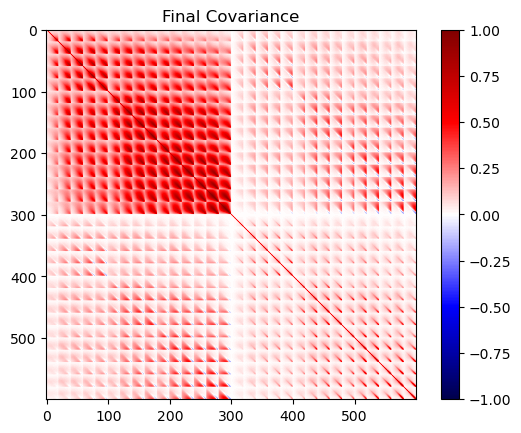

In [9]:
cov_g, cov_ng, ndata = plot.get_cov("covdata_lssty5.txt")
cov = cov_g + cov_ng
pp_norm = np.zeros((ndata,ndata))
for i in range(ndata):
    for j in range(ndata):
        pp_norm[i][j] = cov[i][j]/ np.sqrt(cov[i][i]*cov[j][j])
        
plt.imshow(pp_norm, cmap = 'seismic', vmin = -1, vmax = 1)
plt.colorbar()
plt.title("Final Covariance")
plt.show()

In [10]:
ffile[1].header.pop('STRT_2', None)
ffile[1].header.pop('NAME_2', None)
ffile[1].header.pop('STRT_3', None)
ffile[1].header.pop('NAME_3', None)
ffile[1].header['STRT_1'] = 300
ffile[1].header['NAXIS1'] = 600
ffile[1].header['NAXIS2'] = 600
ffile[1].data = cov

In [11]:
delve_data = run_dir.parent.parent / "LSSTY5_Data"

ztomo = np.load(delve_data / "ztomo_LSSTY5.npy")
nztomo = np.load(delve_data / "nztomo_LSSTY5.npy")

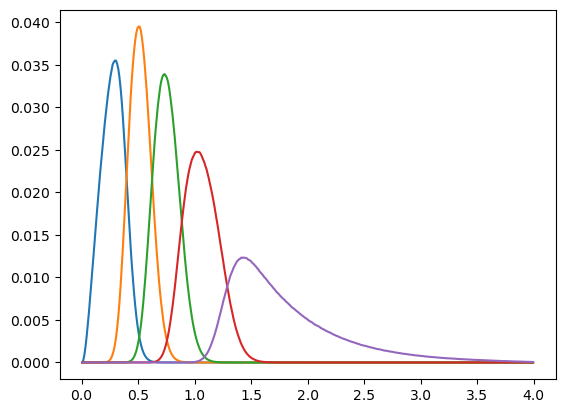

In [12]:
plt.plot(ztomo, nztomo[0], label = 'Source 1')
plt.plot(ztomo, nztomo[1], label = 'Source 2')
plt.plot(ztomo, nztomo[2], label = 'Source 3')
plt.plot(ztomo, nztomo[3], label = 'Source 4')
plt.plot(ztomo, nztomo[4], label = 'Source 5')
plt.show()

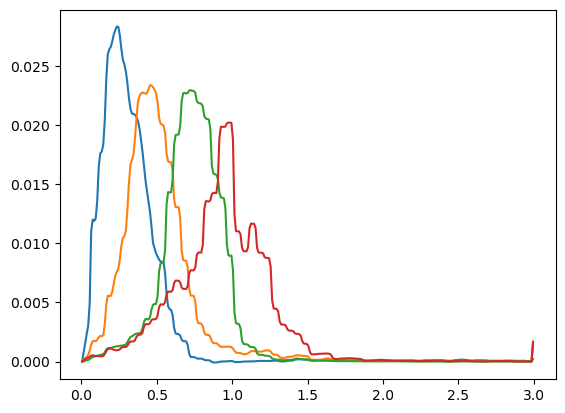

In [13]:
plt.plot(ffile[4].data['Z_MID'], ffile[4].data['BIN1'], label = 'Source 1')
plt.plot(ffile[4].data['Z_MID'], ffile[4].data['BIN2'], label = 'Source 2')
plt.plot(ffile[4].data['Z_MID'], ffile[4].data['BIN3'], label = 'Source 3')
plt.plot(ffile[4].data['Z_MID'], ffile[4].data['BIN4'], label = 'Source 4')
plt.show()

In [15]:
# sigma_e = 0.26 (DESC SRD), neff = 10/arcmin^2 (DESC SRD)
n_density = [4.2, 4.2, 4.2, 4.2, 4.2]

sigma_all = [0.26, 
             0.26,
             0.26,
             0.26,
             0.26]

zhead = ffile[4].header
zhead['NBIN'] = 5
zhead['NZ'] = 400

for i in range(5):
    zhead[f'NGAL_{i + 1}'] = n_density[i]
for i in range(5):
    zhead[f'SIG_E_{i + 1}'] = sigma_all[i]

zdata = ffile[4].data

dtype = np.dtype([
    ('Z_LOW', float), ('Z_MID', float), ('Z_HIGH', float),
    *[(f'BIN{i+1}', float) for i in range(5)]
])
znew = np.recarray(len(ztomo), dtype=dtype)
znew['Z_MID'] = ztomo
znew['Z_LOW'] = ztomo - ztomo[0]
znew['Z_HIGH'] = ztomo + ztomo[0]
for i in range(5):
    znew[f'BIN{i + 1}'] = nztomo[i]
ffile[4].data = znew



In [16]:
save_dirname = Path("LSSTY5_fiducial2pt_A_2pt")
os.makedirs(save_dirname, exist_ok=True)
os.makedirs(save_dirname / "figures", exist_ok=True)
savepath = save_dirname / "LSSTY5_fiducial2pt_A_2pt.fits"

# orig_dirname = Path("giulia_2pt")
# os.makedirs(orig_dirname, exist_ok=True)
# os.makedirs(orig_dirname / "figures", exist_ok=True)
# opath = orig_dirname / "giulia_2pt_example.fits"

ffile.writeto(savepath, overwrite=True)

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

T2 = twopoint.TwoPointFile.from_fits(opath)
oldpath = opath.parent / "figures" / opath.stem
T2.plots(oldpath, colormap='viridis', savepdf=False, latex=False, plot_spectrum=True, plot_kernel=True, plot_cov=True, cov_vmin=None, sharey=True, save_pickle=False, load_pickle=False, remove_pickle=True,label_legend ='', blind_yaxis=False, shade_until=None)

In [17]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

T3 = twopoint.TwoPointFile.from_fits(savepath)
spath = savepath.parent / "figures" / savepath.stem
T3.plots(spath, colormap='viridis', savepdf=False, latex=False, plot_spectrum=True, plot_kernel=True, plot_cov=True, cov_vmin=None, sharey=True, save_pickle=False, load_pickle=False, remove_pickle=True,label_legend ='', blind_yaxis=False, shade_until=None)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving LSSTY5_fiducial2pt_A_2pt/figures/LSSTY5_fiducial2pt_A_2pt_xip


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving LSSTY5_fiducial2pt_A_2pt/figures/LSSTY5_fiducial2pt_A_2pt_xim
Saving LSSTY5_fiducial2pt_A_2pt/figures/LSSTY5_fiducial2pt_A_2pt_nz_source
Saving LSSTY5_fiducial2pt_A_2pt/figures/LSSTY5_fiducial2pt_A_2pt_cov


In [16]:
savefile = fits.open(savepath)
#oldfile = fits.open(opath)

In [17]:
savefile.info()

Filename: DELVE_fiducial_A_2pt/DELVE_fiducial_A_2pt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        13   (400, 400)   float64   
  2  xip           1 BinTableHDU     39   200R x 8C   [K, K, K, D, D, D, D, D]   
  3  xim           1 BinTableHDU     39   200R x 8C   [K, K, K, D, D, D, D, D]   
  4  nz_source     1 BinTableHDU     34   60R x 7C   [D, D, D, D, D, D, D]   


In [23]:
oldfile.info()

Filename: giulia_2pt/giulia_2pt_example.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (1000, 1000)   float64   
  2  xip           1 BinTableHDU     39   200R x 8C   [K, K, K, D, D, D, D, D]   
  3  xim           1 BinTableHDU     39   200R x 8C   [K, K, K, D, D, D, D, D]   
  4  gammat        1 BinTableHDU     37   480R x 7C   [K, K, K, D, D, D, D]   
  5  wtheta        1 BinTableHDU     39   120R x 8C   [K, K, K, D, D, D, D, D]   
  6  nz_source     1 BinTableHDU     32   300R x 7C   [D, D, D, D, D, D, D]   
  7  nz_lens       1 BinTableHDU     34   150R x 9C   [D, D, D, D, D, D, D, D, D]   


In [18]:
zhead

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   56 / length of dimension 1                          
NAXIS2  =                   60 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    7 / number of table fields                         
NZDATA  =                    T                                                  
EXTNAME = 'nz_source'                                                           
SIG_E_1 =                0.233                                                  
SIG_E_2 =                0.259                                                  
SIG_E_3 =                0.2